##**Business Case**

###**Jamboree**

####**Information about Business**

#####Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

##**Goal:**
###**How can you help here?**

####Your analysis will help Jamboree in understanding what factors are important in graduate admissions and how these factors are interrelated among themselves. It will also help predict one's chances of admission given the rest of the variables.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
!gdown 1JEjAYtE625Z9Hb_ueZgIEt3F-5xVGh1a

Downloading...
From: https://drive.google.com/uc?id=1JEjAYtE625Z9Hb_ueZgIEt3F-5xVGh1a
To: /content/Jamboree_Admission.csv
100% 16.2k/16.2k [00:00<00:00, 32.3MB/s]


In [4]:
data = pd.read_csv('Jamboree_Admission.csv')
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
data.shape


(500, 9)

In [6]:
data.set_index('Serial No.',inplace=True)
data.head()


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


In [7]:
data.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


####Uni and Bi-Varien Analysis

/tmp/ipykernel_5099/1160033671.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(data['GRE Score'], kde=False)


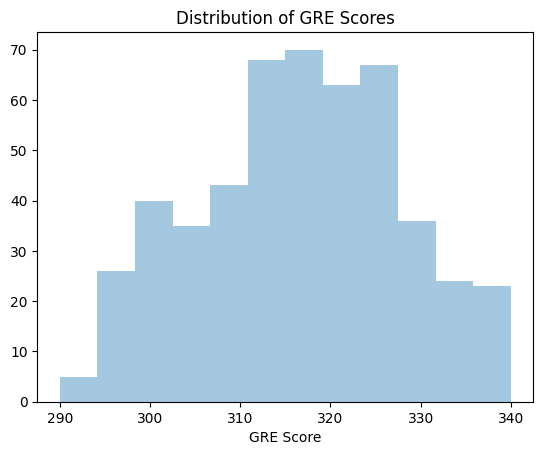

/tmp/ipykernel_5099/1160033671.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(data['TOEFL Score'], kde=False)


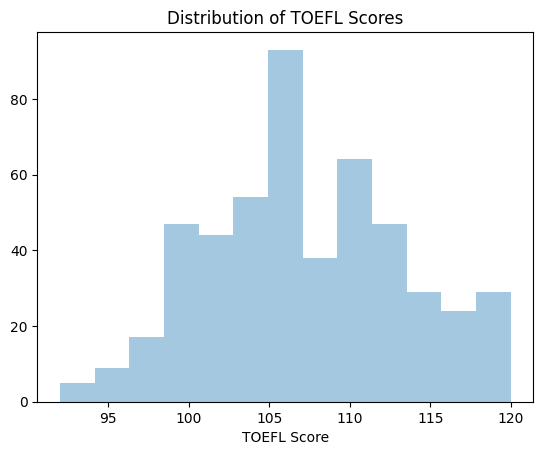

/tmp/ipykernel_5099/1160033671.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(data['University Rating'], kde=False)


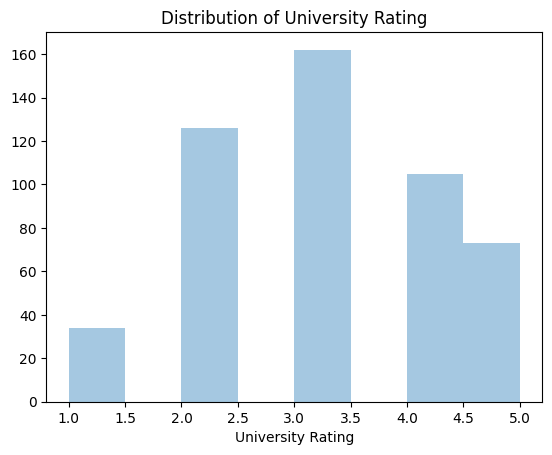

/tmp/ipykernel_5099/1160033671.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(data['SOP'], kde=False)


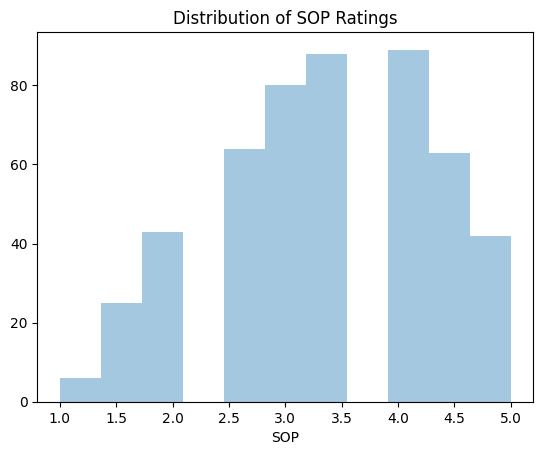

/tmp/ipykernel_5099/1160033671.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  fig = sns.distplot(data['CGPA'], kde=False)


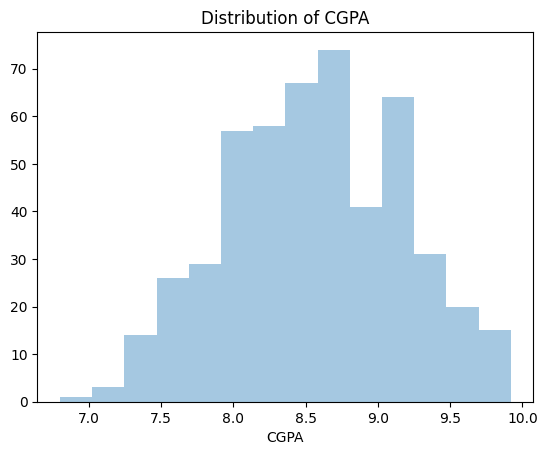

In [8]:
fig = sns.distplot(data['GRE Score'], kde=False)
plt.title("Distribution of GRE Scores")
plt.show()

fig = sns.distplot(data['TOEFL Score'], kde=False)
plt.title("Distribution of TOEFL Scores")
plt.show()

fig = sns.distplot(data['University Rating'], kde=False)
plt.title("Distribution of University Rating")
plt.show()

fig = sns.distplot(data['SOP'], kde=False)
plt.title("Distribution of SOP Ratings")
plt.show()

fig = sns.distplot(data['CGPA'], kde=False)
plt.title("Distribution of CGPA")
plt.show()

plt.show()

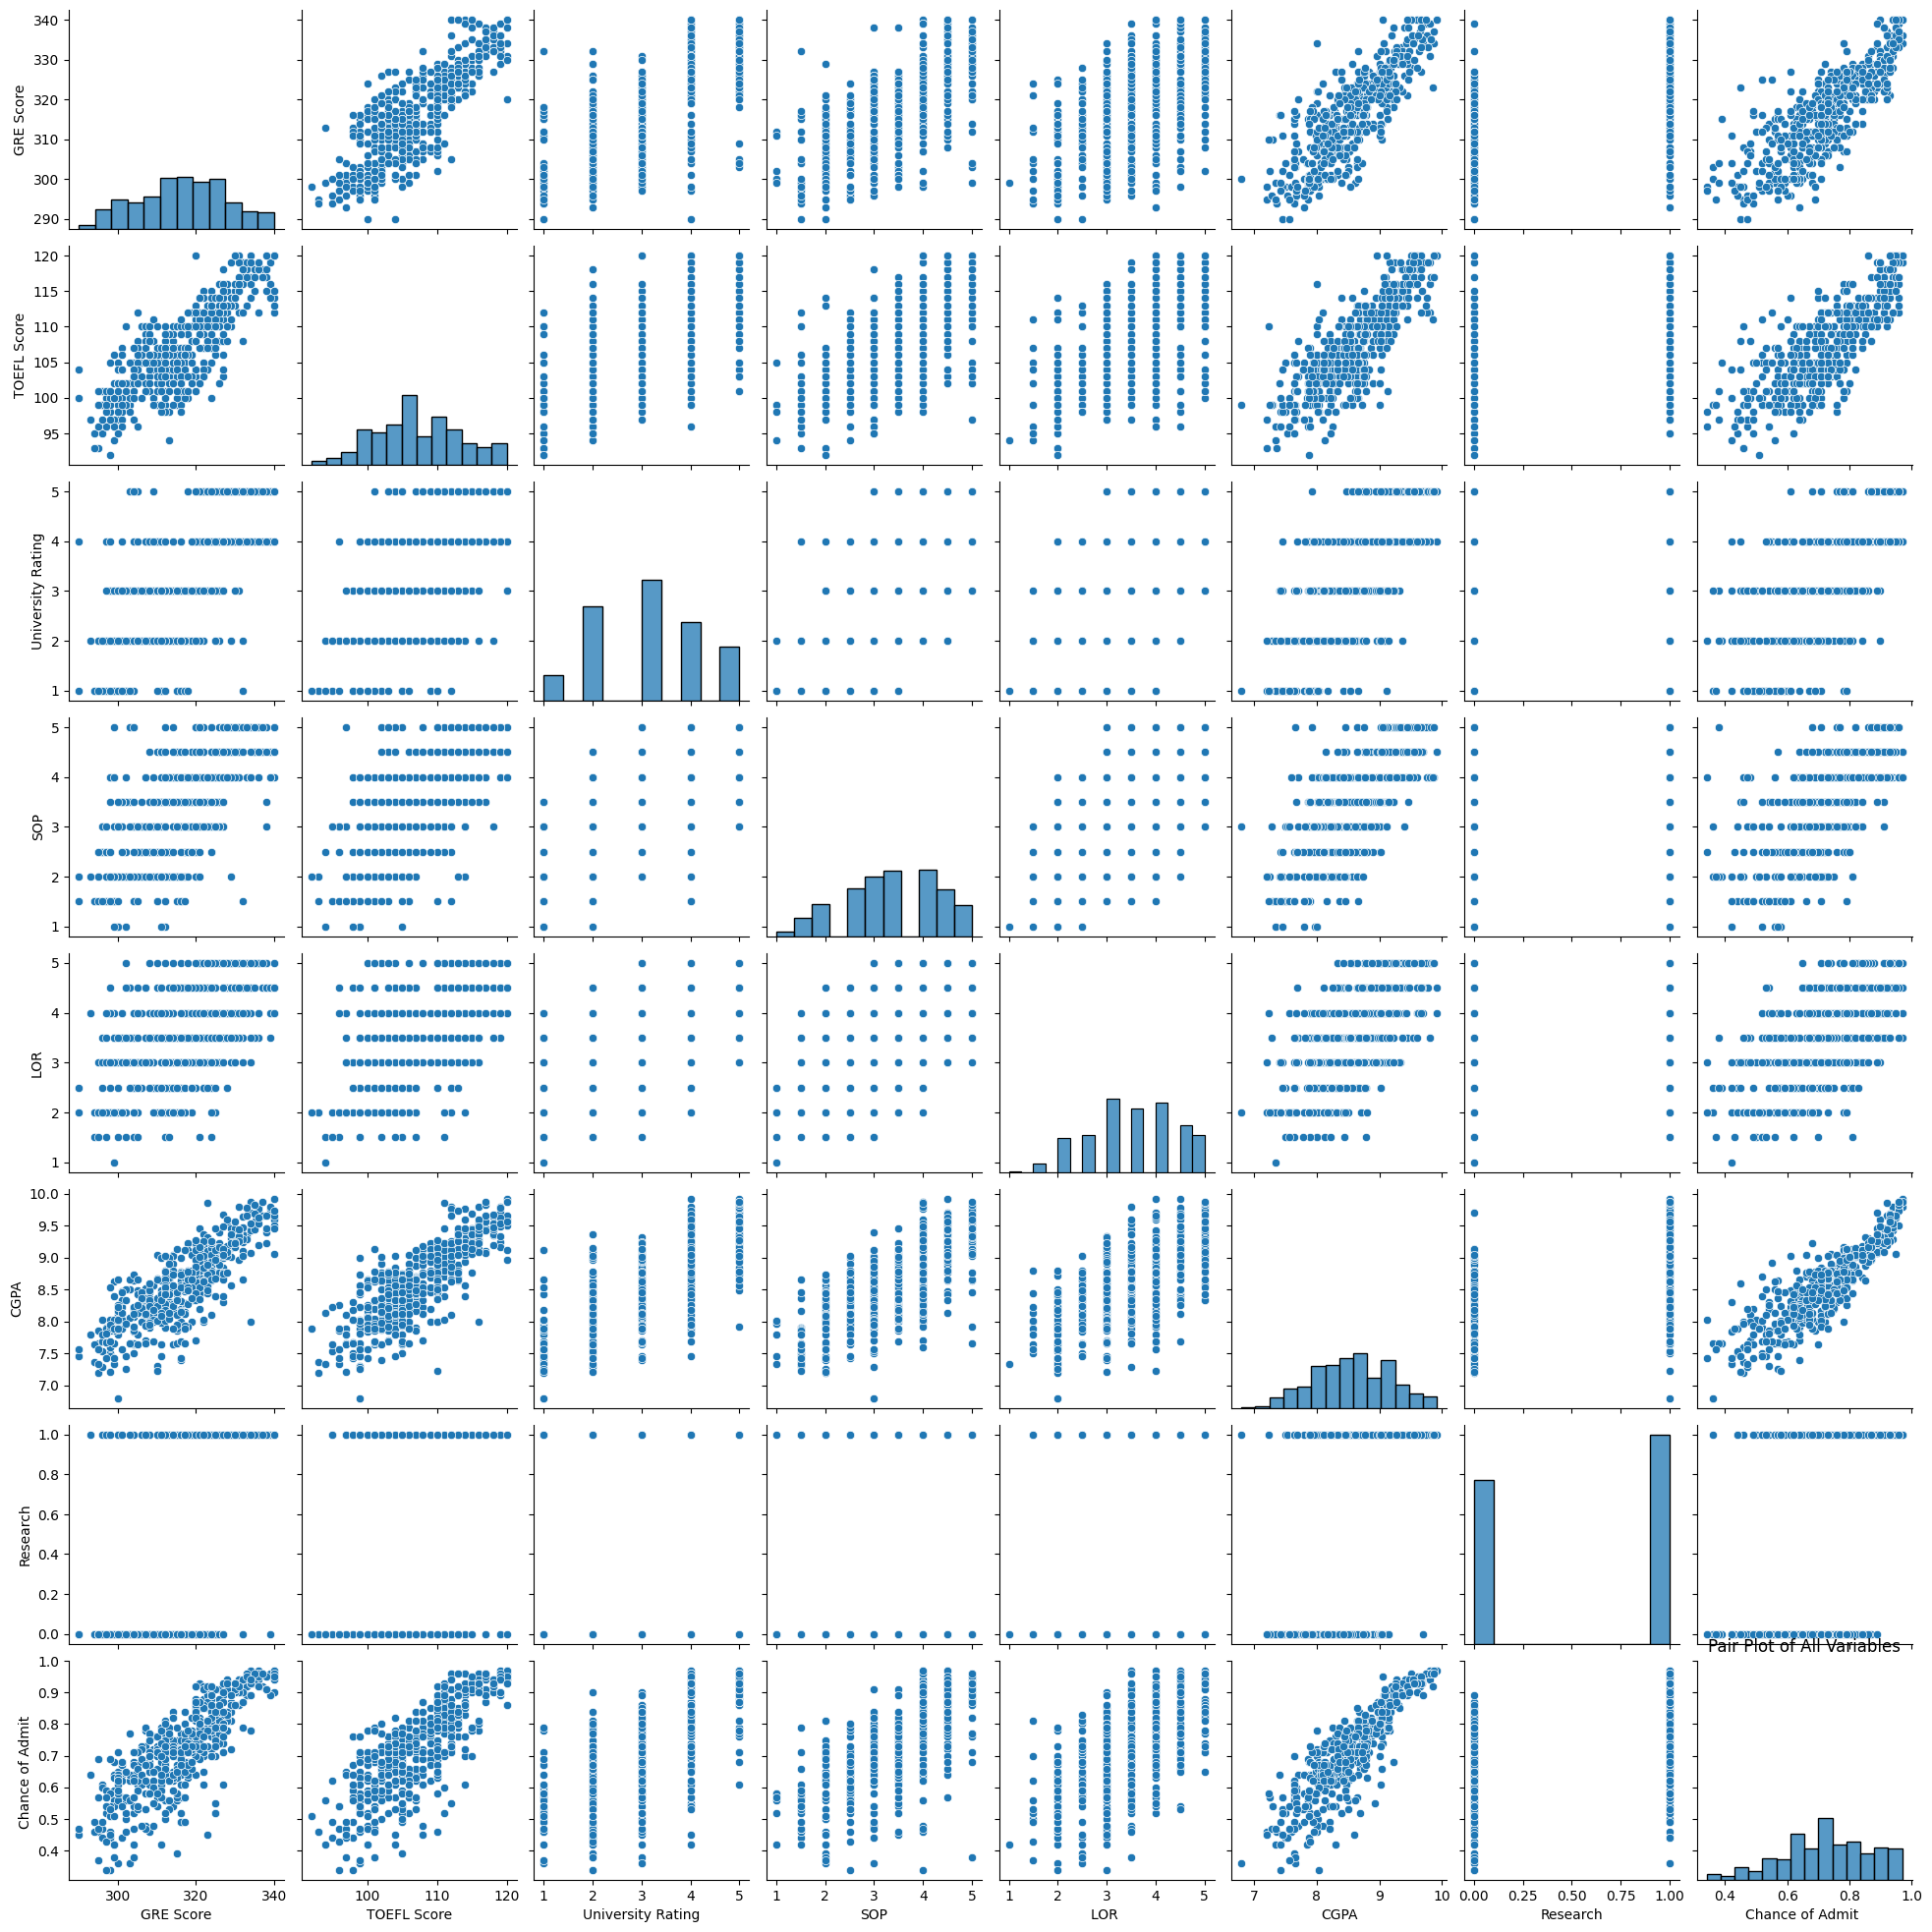

In [9]:
sns.pairplot(data)
plt.title('Pair Plot of All Variables')
plt.show()

#####Checking for Multicolinearity for the variables. As seen the pair plot, most of the variables should be highly colinear. The Heatmap should confirm the same

We will plot the heatmap and check the information

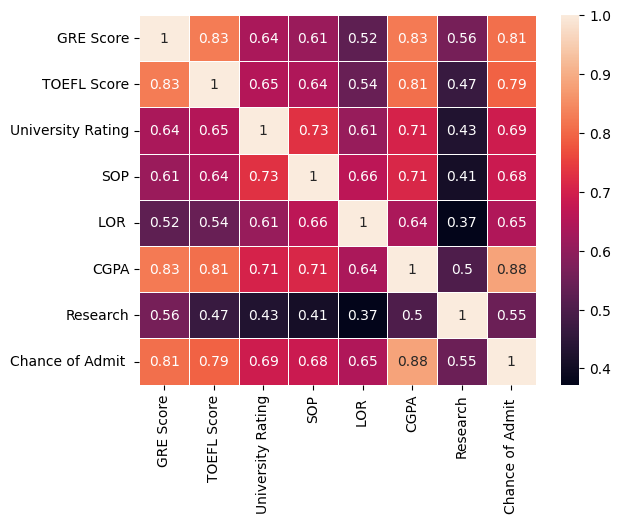

In [10]:
corr = data.corr()
sns.heatmap(corr, linewidths=.5, annot=True)
plt.show()

####Before checking for Outliers, lets split the data into train and test split

In [11]:
X = data.drop(['Chance of Admit '], axis=1)
y = data['Chance of Admit ']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20, shuffle=True)

####OUTLIER detection
Plotting a boxplot for all the variables to see if there are any outliears in the data

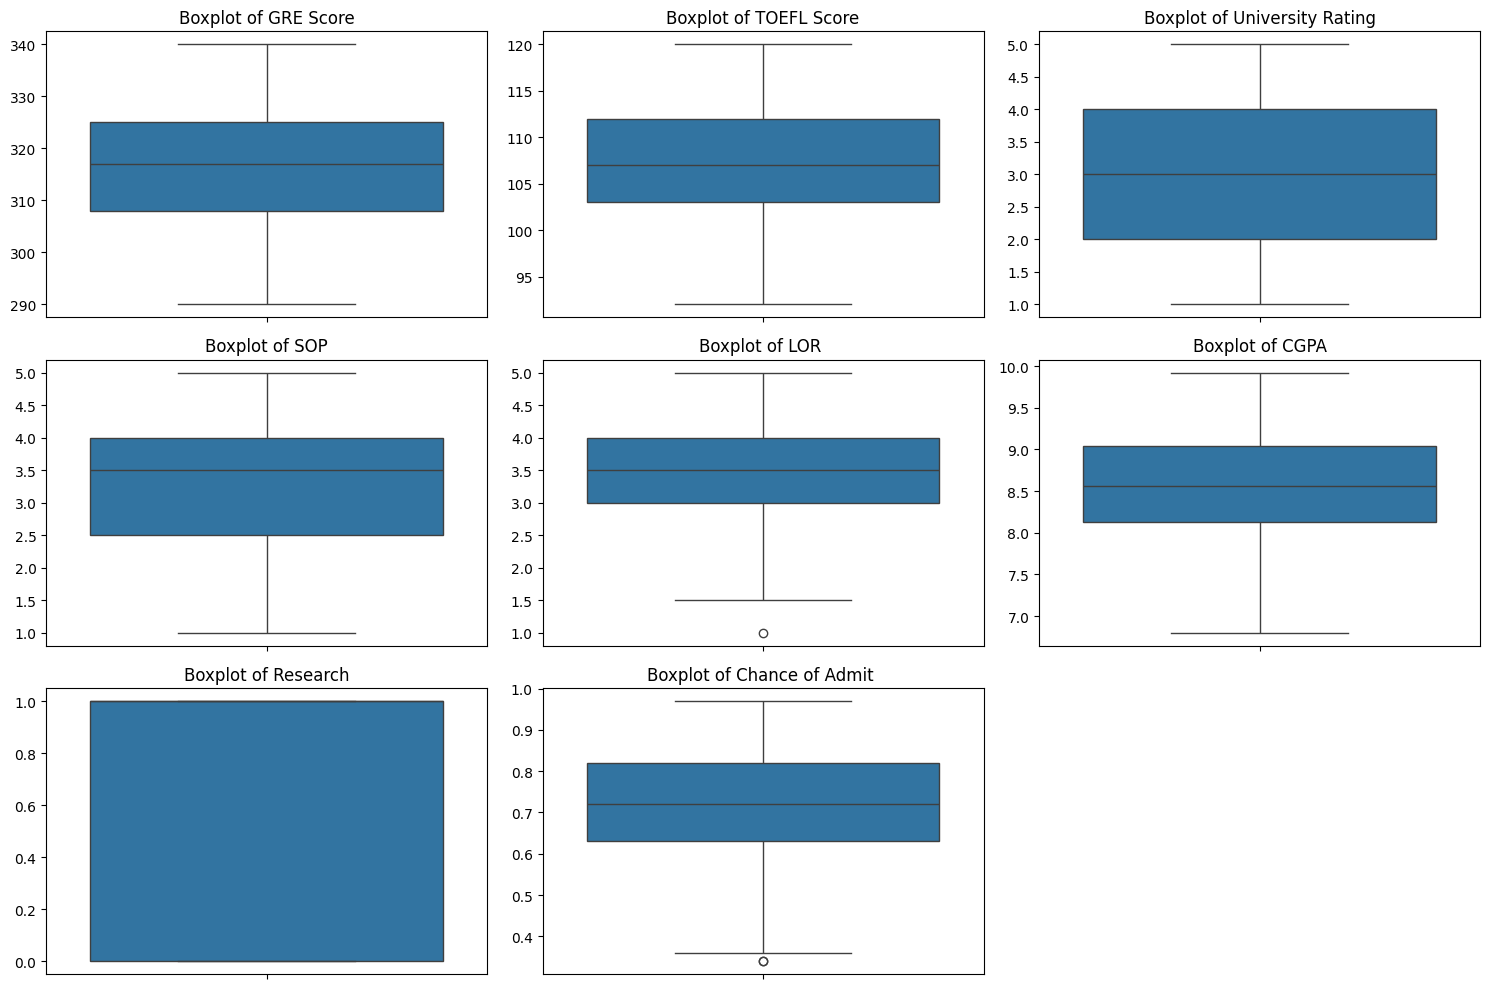

In [12]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(data.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed based on number of columns
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('') # Remove y-label for cleaner plot
plt.tight_layout()
plt.show()

#### After ploting a box plot we don't see any huge outliers and we can carry on with Standard scaler

####Applying minmaxscaler to standadise the numerical values

In [13]:
from sklearn.preprocessing import StandardScaler
X_train_columns=X_train.columns
std=StandardScaler()
X_train_std=std.fit_transform(X_train)


In [14]:
X_train=pd.DataFrame(X_train_std, columns=X_train_columns)
X_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.213717,-0.367073,0.806037,0.658703,1.081931,0.142031,0.881917
1,-1.699520,-1.005461,-0.072477,-1.368075,0.548303,-1.483058,0.881917
2,0.387648,0.750106,-0.072477,-0.354686,1.081931,0.618068,0.881917
3,-1.438624,-0.367073,-1.829506,-2.381465,-1.586209,-1.269663,-1.133893
4,0.474613,-0.686267,0.806037,-0.354686,-1.052581,-0.908532,0.881917


In [15]:
data.corr()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL Score,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012,0.792228
University Rating,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance of Admit,0.810351,0.792228,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


####We will be running multiple regression model at once. We will import linear regression, lasso, ridge regression as well.

In [16]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso,Ridge,LinearRegression
from sklearn.metrics import mean_squared_error

models = [
           ['Linear Regression :', LinearRegression()],

          ['Lasso Regression :', Lasso(alpha=0.1)], #try with different alpha values
          ['Ridge Regression :', Ridge(alpha=1.0)] #try with different alpha values
          ]

print("Results without removing features with multicollinearity ...")


for name,model in models:
    model.fit(X_train, y_train.values)
    predictions = model.predict(std.transform(X_test))
    print(name, (np.sqrt(mean_squared_error(y_test, predictions))))

Results without removing features with multicollinearity ...
Linear Regression : 0.06946166758886134
Lasso Regression : 0.12164813668130785
Ridge Regression : 0.06944613918964723


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [17]:

r2 = r2_score(y_test, predictions)
print("R2 Score: ", r2)

R2 Score:  0.7592539832169551


#### Running the linear regression using Statsmodels as we can get more information on the test and we can determine which colums we can drop

In [18]:
import statsmodels.api as sm
X_train = sm.add_constant(X_train)
model = sm.OLS(y_train.values, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     287.6
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          4.13e-150
Time:                        06:33:11   Log-Likelihood:                 579.28
No. Observations:                 400   AIC:                            -1143.
Df Residuals:                     392   BIC:                            -1111.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7229      0.00

In [19]:
X_train_new=X_train.drop(columns=['SOP'])
model1 = sm.OLS(y_train.values, X_train_new).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     336.2
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          2.30e-151
Time:                        06:33:11   Log-Likelihood:                 579.21
No. Observations:                 400   AIC:                            -1144.
Df Residuals:                     393   BIC:                            -1116.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7229      0.00

In [20]:
X_train_new=X_train.drop(columns=['SOP', 'University Rating'])
model1 = sm.OLS(y_train.values, X_train_new).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     399.9
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          7.20e-152
Time:                        06:33:11   Log-Likelihood:                 577.29
No. Observations:                 400   AIC:                            -1143.
Df Residuals:                     394   BIC:                            -1119.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7229      0.003    251.099      

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataset,col):
  dataset=dataset.drop(columns=col,axis=1)
  vif=pd.DataFrame()
  vif['features']=dataset.columns
  vif['VIF_Value']=[variance_inflation_factor(dataset.values,i) for i in range(dataset.shape[1])]
  return vif

In [22]:
calculate_vif(X_train_new,[])

,features,VIF_Value
0,const,1.000000
1,GRE Score,4.527560
2,TOEFL Score,3.931407
3,LOR,1.690179
4,CGPA,4.150819
5,Research,1.528766


In [23]:
X_test_std = std.transform(X_test)
X_test_df = pd.DataFrame(X_test_std, columns=X_test.columns)
X_test_new = sm.add_constant(X_test_df, has_constant='add')
X_test_new = X_test_new.drop(columns=['SOP', 'University Rating'])

In [24]:
pred = model1.predict(X_test_new)

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

print('Mean Absolute Error ', mean_absolute_error(y_test.values,pred) )
print('Root Mean Square Error ', np.sqrt(mean_squared_error(y_test.values,pred) ))

Mean Absolute Error  0.04657383180374878
Root Mean Square Error  0.06938285755072883


In [25]:
residuals = y_test.values-pred
mean_residuals = np.mean(residuals)
print("Mean of Residuals {}".format(mean_residuals))

Mean of Residuals -0.005062076782078053


###Test for Homoscedasticity

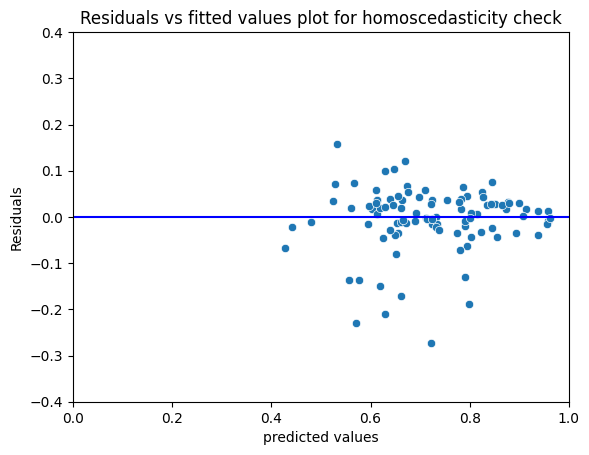

In [26]:
p = sns.scatterplot(x=pred, y=residuals)
plt.xlabel('predicted values')
plt.ylabel('Residuals')
plt.ylim(-0.4, 0.4)
plt.xlim(0, 1)
p = sns.lineplot(x=[0, 26], y=[0, 0], color='blue')
p = plt.title('Residuals vs fitted values plot for homoscedasticity check')

/tmp/ipykernel_5099/3040778317.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p = sns.distplot(residuals,kde=True)


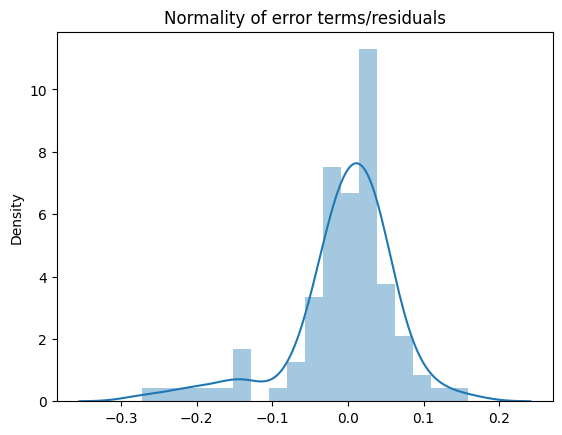

In [27]:
p = sns.distplot(residuals,kde=True)
p = plt.title('Normality of error terms/residuals')